In [ ]:
"""
Image variants ported from monolithic/apis/fastapi_app.py (/process-images).

Pipeline matches the monolith: PIL RGB -> float32 / 255, then OpenCV filters.
"""

from collections.abc import Callable
from io import BytesIO

import cv2
import numpy as np
from PIL import Image


def _load_normalized(contents: bytes) -> np.ndarray:
    img_pil = Image.open(BytesIO(contents)).convert("RGB")
    return np.array(img_pil, dtype=np.float32) / 255.0


def _rgb_u8_to_jpeg(rgb: np.ndarray) -> bytes:
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    _, buf = cv2.imencode(".jpg", bgr)
    return buf.tobytes()


def get_heatmap_image(image_array: np.ndarray):
    img = (
        cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if image_array.max() <= 1
        else image_array
    )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    heatmap = cv2.applyColorMap(gray, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return img_rgb, gray, heatmap_rgb


def get_canny_edges(image_array: np.ndarray, threshold1=100, threshold2=200):
    img = (
        cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if image_array.max() <= 1
        else image_array
    )
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1, threshold2)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    return edges_rgb


def get_clahe_enhanced(image_array: np.ndarray, clipLimit=2.0, tileGridSize=(8, 8)):
    img = (
        cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if image_array.max() <= 1
        else image_array
    )
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    enhanced = clahe.apply(gray)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    return enhanced_rgb


def get_morphological_result(image_array: np.ndarray, operation="open"):
    img = (
        cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if image_array.max() <= 1
        else image_array
    )
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    if operation == "open":
        result = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    elif operation == "close":
        result = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    elif operation == "dilate":
        result = cv2.dilate(thresh, kernel, iterations=1)
    elif operation == "erode":
        result = cv2.erode(thresh, kernel, iterations=1)
    else:
        result = thresh

    result_rgb = cv2.cvtColor(result, cv2.COLOR_GRAY2RGB)
    return result_rgb


def get_contours(image_array: np.ndarray, min_area=100, exclude_largest=True):
    img = (
        cv2.cvtColor((image_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if image_array.max() <= 1
        else image_array
    )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 210, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)

    if exclude_largest and len(contours_sorted) > 0:
        filtered_contours = [
            c for c in contours_sorted[1:] if cv2.contourArea(c) > min_area
        ]
        contour_count = len(filtered_contours)
    else:
        filtered_contours = [
            c for c in contours_sorted if cv2.contourArea(c) > min_area
        ]
        contour_count = len(filtered_contours)

    img_with_contours = img_rgb.copy()
    cv2.drawContours(img_with_contours, filtered_contours, -1, (0, 255, 0), 2)

    return img_rgb, img_with_contours, contour_count


# -----------------------------
# VARIANTS (REORDERED ONLY)
# -----------------------------

def variant_original(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)
    original, _, _ = get_heatmap_image(img_array)
    return _rgb_u8_to_jpeg(original)


def variant_clahe_enhanced(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)
    enhanced = get_clahe_enhanced(img_array, clipLimit=2.0, tileGridSize=(8, 8))
    return _rgb_u8_to_jpeg(enhanced)


def variant_heatmap(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)
    _, _, heatmap = get_heatmap_image(img_array)
    return _rgb_u8_to_jpeg(heatmap)


def variant_canny_edges(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)
    edges = get_canny_edges(img_array, 100, 200)
    return _rgb_u8_to_jpeg(edges)


def variant_morphological_dilate(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)

    img = (
        cv2.cvtColor((img_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        if img_array.max() <= 1
        else img_array
    )

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # threshold
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # OPEN → remove noise
    morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # CLOSE → fill holes
    morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel)

    # convert to RGB
    result_rgb = cv2.cvtColor(morph, cv2.COLOR_GRAY2RGB)

    return _rgb_u8_to_jpeg(result_rgb)


def variant_contours_detected(contents: bytes) -> bytes:
    img_array = _load_normalized(contents)
    _, contours_img, _ = get_contours(img_array, min_area=100, exclude_largest=False)
    return _rgb_u8_to_jpeg(contours_img)

# -----------------------------
# FINAL ORDERED REGISTRY
# -----------------------------

VARIANTS: dict[str, Callable[[bytes], bytes]] = {
    "original": variant_original,
    "clahe_enhanced": variant_clahe_enhanced,
    "heatmap": variant_heatmap,
    "canny_edges": variant_canny_edges,
    "morphological_open-close": variant_morphological_dilate,
    "contours_detected": variant_contours_detected,
}

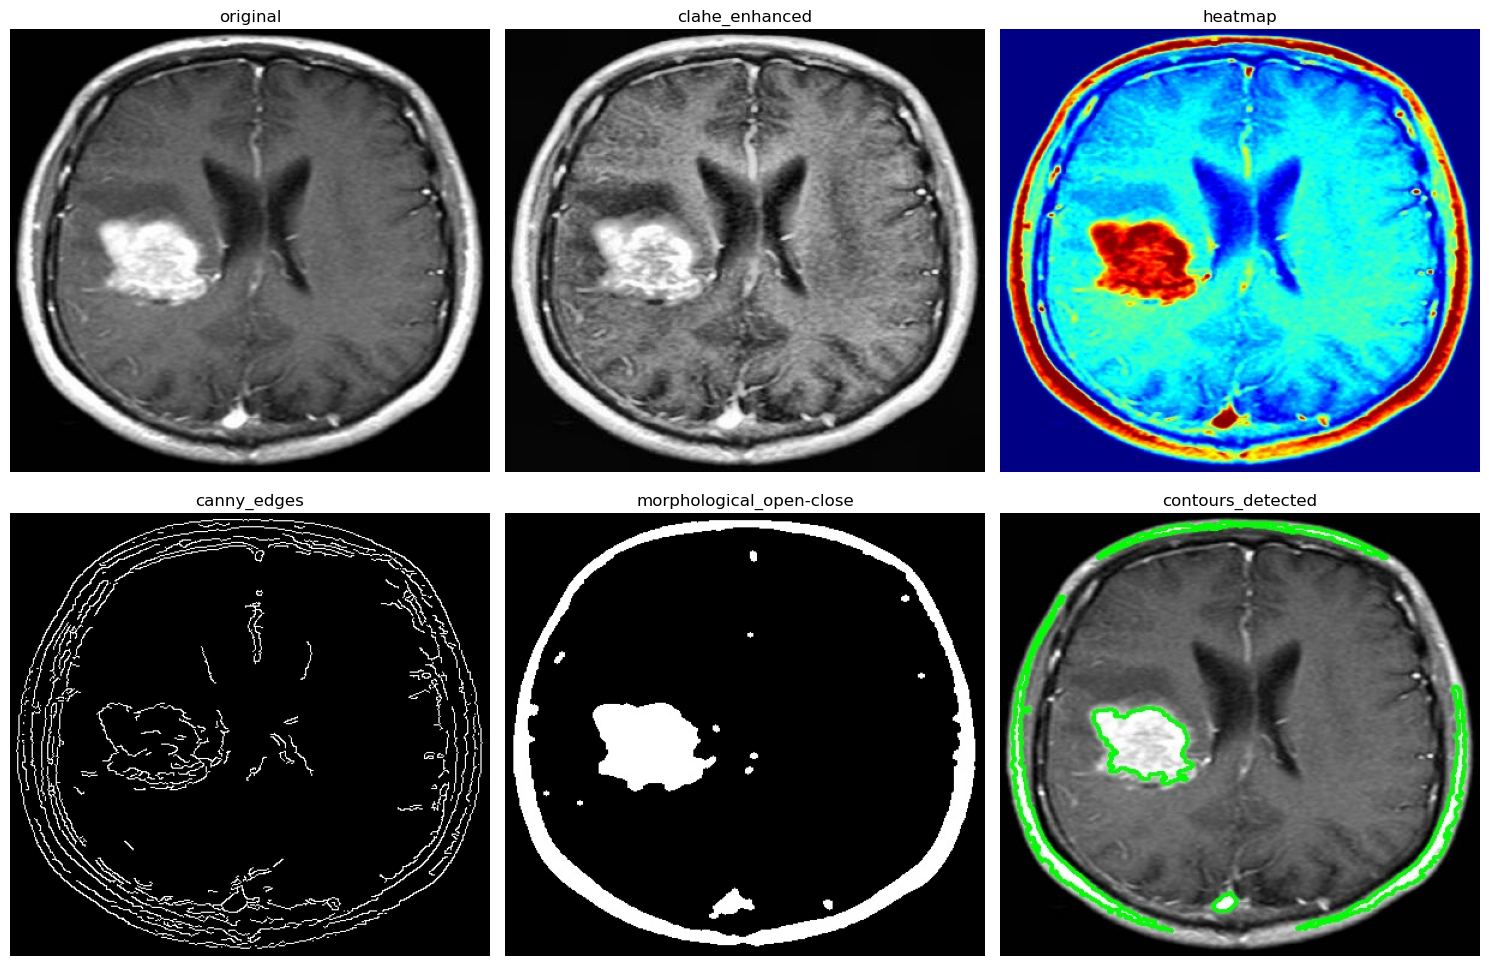

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


IMAGE_PATH = "./test_images/yes/Y11.jpg"


def load_image_bytes(path: str) -> bytes:
    with open(path, "rb") as f:
        return f.read()


def decode_jpeg(jpeg_bytes: bytes):
    img = cv2.imdecode(np.frombuffer(jpeg_bytes, np.uint8), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# load input
image_bytes = load_image_bytes(IMAGE_PATH)

results = {}

# run variants in defined order
for name, fn in VARIANTS.items():
    try:
        out = fn(image_bytes)
        results[name] = decode_jpeg(out)
    except Exception as e:
        print(f"{name} failed: {e}")


# -----------------------
# plot grid
# -----------------------
n = len(results)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(15, 5 * rows))

for i, (name, img) in enumerate(results.items(), 1):
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()